# 03c. Height-marker split for large merged clusters

Graph region growing can still merge touching fragments. This notebook applies a conservative height-field marker split to oversized clusters.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.segmentation.watershed_split import split_large_clusters_by_height_markers
from src.segmentation.graph_region_growing import cluster_size_table
from src.segmentation.metrics import clustering_scores

GRAPH_PATH = PROJECT_ROOT / 'data' / 'labels' / 'synthetic_rockpile_exterior_graph_segmentation.npz'
LABEL_PATH = PROJECT_ROOT / 'data' / 'labels' / 'synthetic_rockpile_exterior_surface_segmentation.npz'
TABLE_PATH = PROJECT_ROOT / 'outputs' / 'tables' / 'surface_segmentation_metrics.csv'
FIG_PATH = PROJECT_ROOT / 'outputs' / 'figures' / 'synthetic_rockpile_surface_segmentation_split.png'
LABEL_PATH.parent.mkdir(parents=True, exist_ok=True)
TABLE_PATH.parent.mkdir(parents=True, exist_ok=True)
FIG_PATH.parent.mkdir(parents=True, exist_ok=True)

In [2]:
data = np.load(GRAPH_PATH)
points = data['points_xyz']
true_labels = data['instance_labels']
labels_graph = data['labels_graph']
print(points.shape, len(np.unique(true_labels)), len(np.unique(labels_graph[labels_graph >= 0])))

(68516, 3) 500 545


In [3]:
params = dict(
    max_cluster_points=180,
    grid_resolution_m=0.030,
    min_peak_distance_m=0.10,
    peak_prominence_m=0.015,
    min_child_points=15,
    max_markers_per_cluster=12,
)
labels_surface = split_large_clusters_by_height_markers(points, labels_graph, **params)
metrics = clustering_scores(true_labels, labels_surface)
metrics.update(cluster_size_table(labels_surface))
metrics.update(params)
metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(TABLE_PATH, index=False)
np.savez_compressed(LABEL_PATH, points_xyz=points, instance_labels=true_labels, labels_surface=labels_surface)
metrics_df

,adjusted_rand_index,normalized_mutual_info,n_true_fragments,n_predicted_clusters,noise_fraction,n_clusters,median_cluster_points,max_cluster_points,grid_resolution_m,min_peak_distance_m,peak_prominence_m,min_child_points,max_markers_per_cluster
0,0.003969,0.540784,500,560,0.428834,560,39.0,180,0.03,0.1,0.015,15,12


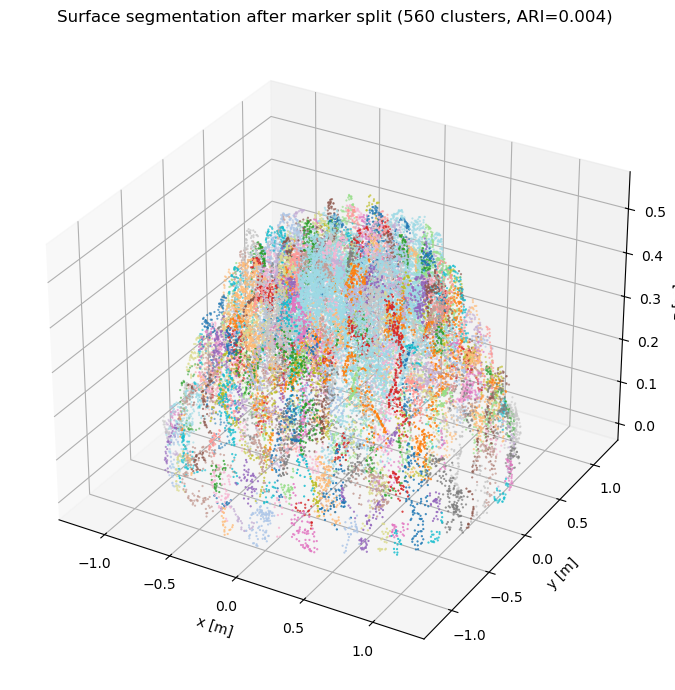

In [4]:
rng = np.random.default_rng(13)
idx = rng.choice(len(points), size=min(60000, len(points)), replace=False)
plot_labels = labels_surface[idx].astype(float)
plot_labels[plot_labels < 0] = np.nan

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[idx,0], points[idx,1], points[idx,2], c=plot_labels, s=0.35, cmap='tab20')
ax.set_title(f"Surface segmentation after marker split ({metrics['n_predicted_clusters']} clusters, ARI={metrics['adjusted_rand_index']:.3f})")
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]'); ax.set_zlabel('z [m]')
plt.tight_layout()
plt.savefig(FIG_PATH, dpi=180)
plt.show()